In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [3]:
init_values = np.array([
    [3.3832, 3.9071, 3.1023, -0.4984, 0.0893, -4.5524, -2.4730, -1.84],
    [2.5911, 4.3366, 2.3102, -0.4555, 0.1323, -4.5569, -2.4774,-1.96],
    [4.7835, 7.5797, 4.5026, -0.1312, 0.4566, -3.6849, -2.6055,-1.23],
    [2.0460, 2.1157, 1.8651, -1.1007, -0.5129, -4.6103, -2.5308,-1.10],
    [1.7275, 7.0000, 1.4400, -0.1399, 0.4400, -3.9645, -2.8850,-0.83],
    [2.4872, 2.3469, 2.2063, -0.6545, -0.0667, -4.4198, -2.3403,-1.63],
    [4.5758, 8.7864, 4.2949, -0.0105, 0.5773, -4.7410, -2.6616,-1.65],
    [4.1007, 4.1830, 3.8198, -0.1709, 0.4169, -3.1980, -3.1185, -1.71],
    [2.4385, 4.9806, 2.1576, -0.9872, -0.3994, -2.7566, -1.6772,-2.14],
    [1.6563, 5.9819, 1.3754, -0.2910, 0.2968, -3.5078, -1.4283,-2.63],
])

In [23]:
simu_ab = np.loadtxt('antibody_datasets/real_ab_convergence_initparams.txt')
# simu_ab = np.c_[ simu_ab, init_values[:,-1] ]


In [24]:
simu_ab

array([[ 3.3832,  3.9071,  3.1023, -0.4984,  0.0893, -4.5524, -2.473 ,
        -1.84  ],
       [ 2.5911,  4.3366,  2.3102, -0.4555,  0.1323, -4.5569, -2.4774,
        -1.96  ],
       [ 4.7835,  7.5797,  4.5026, -0.1312,  0.4566, -3.6849, -2.6055,
        -1.23  ],
       [ 2.046 ,  3.1157,  1.7651, -0.707 , -0.3129, -3.6103, -2.5308,
        -1.1   ],
       [ 1.7275,  7.    ,  1.44  , -0.1399,  0.44  , -3.9645, -2.885 ,
        -1.33  ],
       [ 2.4872,  2.3469,  2.2063, -0.6545, -0.0667, -4.4198, -2.3403,
        -1.63  ],
       [ 4.5758,  8.7864,  4.2949, -0.0105,  0.5773, -4.741 , -2.6616,
        -1.65  ],
       [ 4.1007,  4.183 ,  3.8198, -0.1709,  0.4169, -3.198 , -3.1185,
        -1.71  ],
       [ 2.4385,  4.9806,  2.1576, -0.9872, -0.3994, -2.7566, -1.6772,
        -2.14  ],
       [ 1.6563,  5.9819,  1.3754, -0.291 ,  0.2968, -3.5078, -1.4283,
        -2.63  ]])

In [25]:
np.exp(simu_ab[:,[-2,-1]])

array([[0.08433148, 0.15881743],
       [0.08396124, 0.14085842],
       [0.07386619, 0.29229258],
       [0.07959532, 0.33287108],
       [0.05585479, 0.26447726],
       [0.09629874, 0.19592957],
       [0.06983639, 0.19204991],
       [0.04422345, 0.18086579],
       [0.18689655, 0.11765484],
       [0.23971609, 0.07207846]])

In [7]:
np.savetxt('antibody_datasets/simu_ab_convergence_initparams.txt', simu_ab, fmt='%.4f')

In [4]:
for j, init_param in enumerate(init_values):

    new_order = [0, 1, 2, 3, 4, 7, 5, 6]
    init_param = init_param[new_order]
    print(init_param)

[ 3.3832  3.9071  3.1023 -0.4984  0.0893 -1.84   -4.5524 -2.473 ]
[ 2.5911  4.3366  2.3102 -0.4555  0.1323 -1.96   -4.5569 -2.4774]
[ 4.7835  7.5797  4.5026 -0.1312  0.4566 -1.23   -3.6849 -2.6055]
[ 2.046   2.1157  1.8651 -1.1007 -0.5129 -1.     -4.6103 -2.5308]
[ 1.7275  7.      1.44   -0.1399  0.44   -0.83   -3.9645 -2.885 ]
[ 2.4872  2.3469  2.2063 -0.6545 -0.0667 -1.63   -4.4198 -2.3403]
[ 4.5758  8.7864  4.2949 -0.0105  0.5773 -0.65   -4.741  -2.6616]
[ 2.4385  4.9806  2.1576 -0.9872 -0.3994 -2.14   -2.7566 -1.6772]
[ 1.6563  5.9819  1.3754 -0.291   0.2968 -2.63   -3.5078 -1.4283]


In [ ]:
#baseline parameter values
params = {
    "k_p": 1.0,
    "p_max": 1.0,
    "k_ap": 1.0,
    "eta_ap": 1.0,
    "k_cp": 0.01,
    "gamma_c": 1.0,
    "gamma_p": 1.0,
    "k_pc": 1.0,
    "phi_c": 0.1,
    "k_s": 0.1,
    "nu": 30.0,
    "t_i": list(range(50, 250, 40)),
    "k_ac": 0.01,
    "eta_ac": 1.0,
    "gamma_a": 0.01,
    "k_b": 1.0,
    "k_pm": 0.1,
    "k_apm": 0.1,
    "eta_apm": 10.0,
    "phi_m": 0.01
}

params3 = {
    "k_p": 1.0,
    "p_max": 1.0,
    "k_ap": 1.0,
    "eta_ap": 1.0,
    "k_cp": 0.01,
    "gamma_c": 1.0,
    "gamma_p": 1.0,
    "k_pc": 1.0,
    "phi_c": 0.05,
    "k_s": 0.1,
    "nu": 30.0,
    "t_i": list(range(50, 550, 40)),
    "k_ac": 0.025,
    "eta_ac": 1.0,
    "gamma_a": 0.01,
    "k_b": 1.0,
    "k_pm": 0.1,
    "k_apm": 0.1,
    "eta_apm": 10.0,
    "phi_m": 0.01
}

params2 = {
    "k_p": 1.5,
    "p_max": 1.0,
    "k_ap": 1.0,
    "eta_ap": 1.0,
    "k_cp": 0.01,
    "gamma_c": 1.0,
    "gamma_p": 1.0,
    "k_pc": 1.0,
    "phi_c": 0.1,
    "k_s": 0.1,
    "nu": 30.0,
    "t_i": list(range(50, 550, 40)),
    "k_ac": 0.01,
    "eta_ac": 1.0,
    "gamma_a": 0.01,
    "k_b": 1.0,
    "k_pm": 0.1,
    "k_apm": 0.1,
    "eta_apm": 10.0,
    "phi_m": 0.01
}

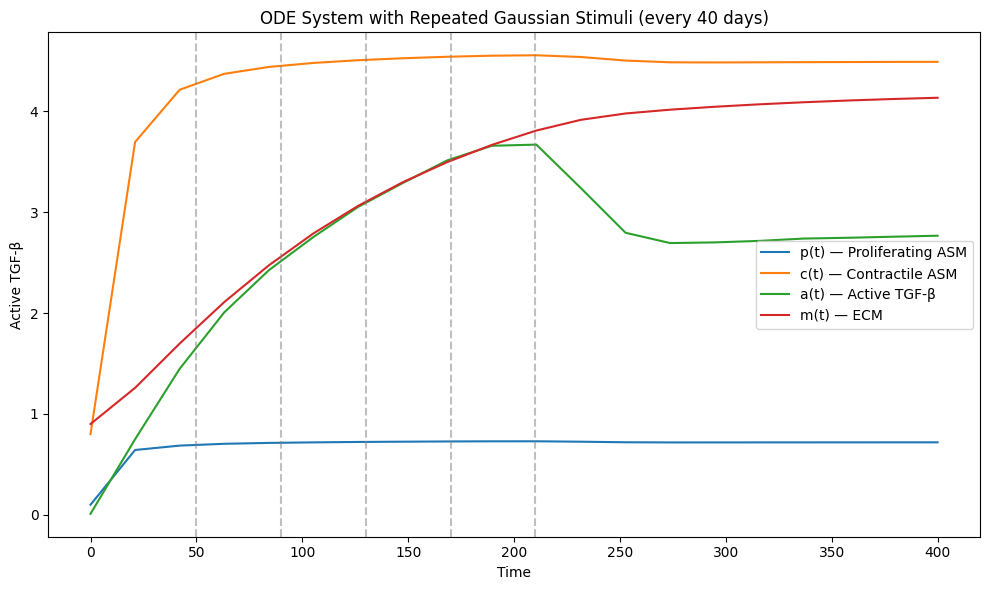

In [24]:
# Define the ODE system
def asthme_vector_field(t, y, params):
    p, c, a, m = y
    k_p = params["k_p"]
    p_max = params["p_max"]
    k_ap = params["k_ap"]
    eta_ap = params["eta_ap"]
    k_cp = params["k_cp"]
    gamma_c = params["gamma_c"]
    gamma_p = params["gamma_p"]
    k_pc = params["k_pc"]
    phi_c = params["phi_c"]
    k_s = params["k_s"]
    nu = params["nu"]
    t_is = params["t_i"]
    k_ac = params["k_ac"]
    eta_ac = params["eta_ac"]
    gamma_a = params["gamma_a"]
    k_b = params["k_b"]
    k_pm = params["k_pm"]
    k_apm = params["k_apm"]
    eta_apm = params["eta_apm"]
    phi_m = params["phi_m"]

    stimulus = sum((k_s / nu) * np.exp(-((t - t_i) ** 2) / nu ** 2) for t_i in t_is)

    # Reduced equations from Eq. 3.3
    dpdt = k_p * p * (1 - p / p_max) * (1 + (k_ap * a * p) / (eta_ap + a * p)) + k_cp * gamma_c / gamma_p * c - k_pc * p
    dcdt = k_pc * gamma_p / gamma_c * p - (k_cp + phi_c) * c
    dadt = (stimulus + (k_ac * a * c) / (eta_ac + a * c)) * c * m / gamma_a - k_b * (gamma_p * p / gamma_c + c) * a - a
    dmdt = (k_pm + (k_apm * a * p) / (eta_apm + a * p)) * gamma_p * p - phi_m * m

    return [dpdt, dcdt, dadt, dmdt]

# Initial conditions
y0 = [0.1, 0.8, 0.01, 0.9]  # P0, C0, A0, M0

# Time span
t_span = (0, 400)
t_eval = np.linspace(*t_span, 20)

# Solve the ODE
sol = solve_ivp(lambda t, y: asthme_vector_field(t, y, params), t_span, y0, t_eval=t_eval)

# # Plot results
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label="p(t) — Proliferating ASM")
plt.plot(sol.t, sol.y[1], label="c(t) — Contractile ASM")
plt.plot(sol.t, sol.y[2], label="a(t) — Active TGF-β")
plt.plot(sol.t, sol.y[3], label="m(t) — ECM")

# Solve the ODE
# sol2 = solve_ivp(lambda t, y: asthme_vector_field(t, y, params2), t_span, y0, t_eval=t_eval)
# sol3 = solve_ivp(lambda t, y: asthme_vector_field(t, y, params3), t_span, y0, t_eval=t_eval)
# Add Gaussian noise to a(t)
# noise_std = 0.2
# a_obs1 = sol.y[2] + np.random.normal(0, noise_std, size=len(sol.y[2]))
# a_obs2 = sol2.y[2] + np.random.normal(0, noise_std, size=len(sol2.y[2]))
# plt.scatter(t_eval, a_obs1, label="Exposed", marker="x")

# plt.plot(t_eval, a_obs2, label="Health", marker="x")

# Show stimulus times
for t_i in params["t_i"]:
    plt.axvline(t_i, color='gray', linestyle='--', alpha=0.5)

plt.xlabel("Time")
plt.ylabel("Active TGF-β")
plt.title("ODE System with Repeated Gaussian Stimuli (every 40 days)")
plt.legend()
plt.tight_layout()
# plt.savefig('raw_data.png')
plt.show()


In [ ]:
import numpy as np
asthme_data = np.load('asthme_datasets/20_400_50_1latent_phiC/dataset_1.npy')
nonoise_asthme_data = np.load('asthme_datasets/20_400_50_1latent_phiC/dataset_nonoise_1.npy')

/tmp/ipykernel_389137/187297214.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


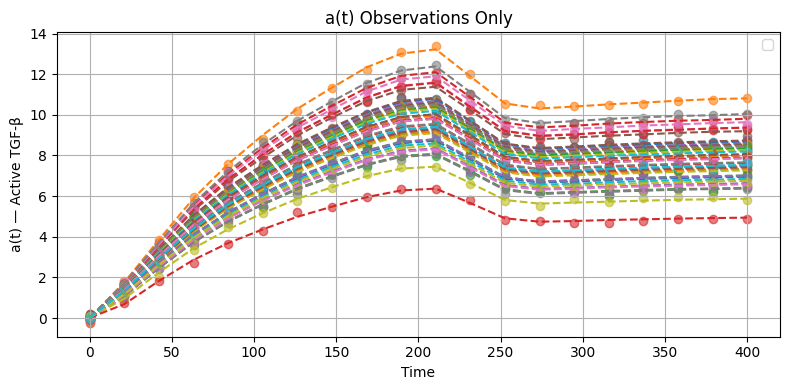

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
indices = list(range(50))
t_eval = np.linspace(0, 400, 20)
for i in indices:
    plt.scatter(t_eval[:], asthme_data[i,:], alpha=0.6)
    plt.plot(t_eval[:], nonoise_asthme_data[i, :], linestyle='--')
plt.xlabel("Time")
plt.ylabel("a(t) — Active TGF-β")
plt.title("a(t) Observations Only")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

true_Kp = np.log(1.15)
true_Kac = np.log(0.01)
true_Kb = np.log(1)
true_std_Kp = np.log(0.05)

alphas = np.linspace(1, 2, 10)
epsilon_pop_1 = np.random.normal(0, 0.5, 10)
epsilon_pop_2 = np.random.normal(0, 0.5, 10)
epsilon_pop_3 = np.random.normal(0, 0.5, 10)
init_Kp_values = true_Kp + alphas * epsilon_pop_1
init_Kac_values = true_phiC + alphas * epsilon_pop_2
init_Kb_values = true_phiC + alphas * epsilon_pop_3

alphas_std = np.linspace(0.1, 0.5, 10)
epsilon_std_1 = np.random.normal(0, 0.5, 10)
init_Kp_stds = true_std_Kp + alphas_std * epsilon_std_1

init_params = list(zip(init_Kp_values, init_Kb_values, init_Kac_values, init_Kp_stds))
np.savetxt('Asthme_1latent_init_params.txt',init_params, fmt='%.4f')
init_params = np.loadtxt('Asthme_1latent_init_params.txt')
print(init_params)

0.0
[[ 0.2973 -2.2097 -0.7058 -0.6665]
 [-0.9024 -2.4337 -0.7451 -0.6562]
 [-0.8693 -1.602  -0.8162 -0.5445]
 [ 1.0477 -2.3003 -0.7971 -0.5831]
 [-0.2738 -1.7914 -0.6242 -0.5117]
 [-0.9601 -3.7036 -0.7353 -0.6833]
 [-0.5307 -2.4379 -0.7604 -0.9254]
 [-0.2202 -1.7233 -0.8322 -0.4751]
 [-0.1704 -3.0141 -0.8209 -0.7818]
 [ 0.8135 -1.7373 -1.0486 -0.5743]]


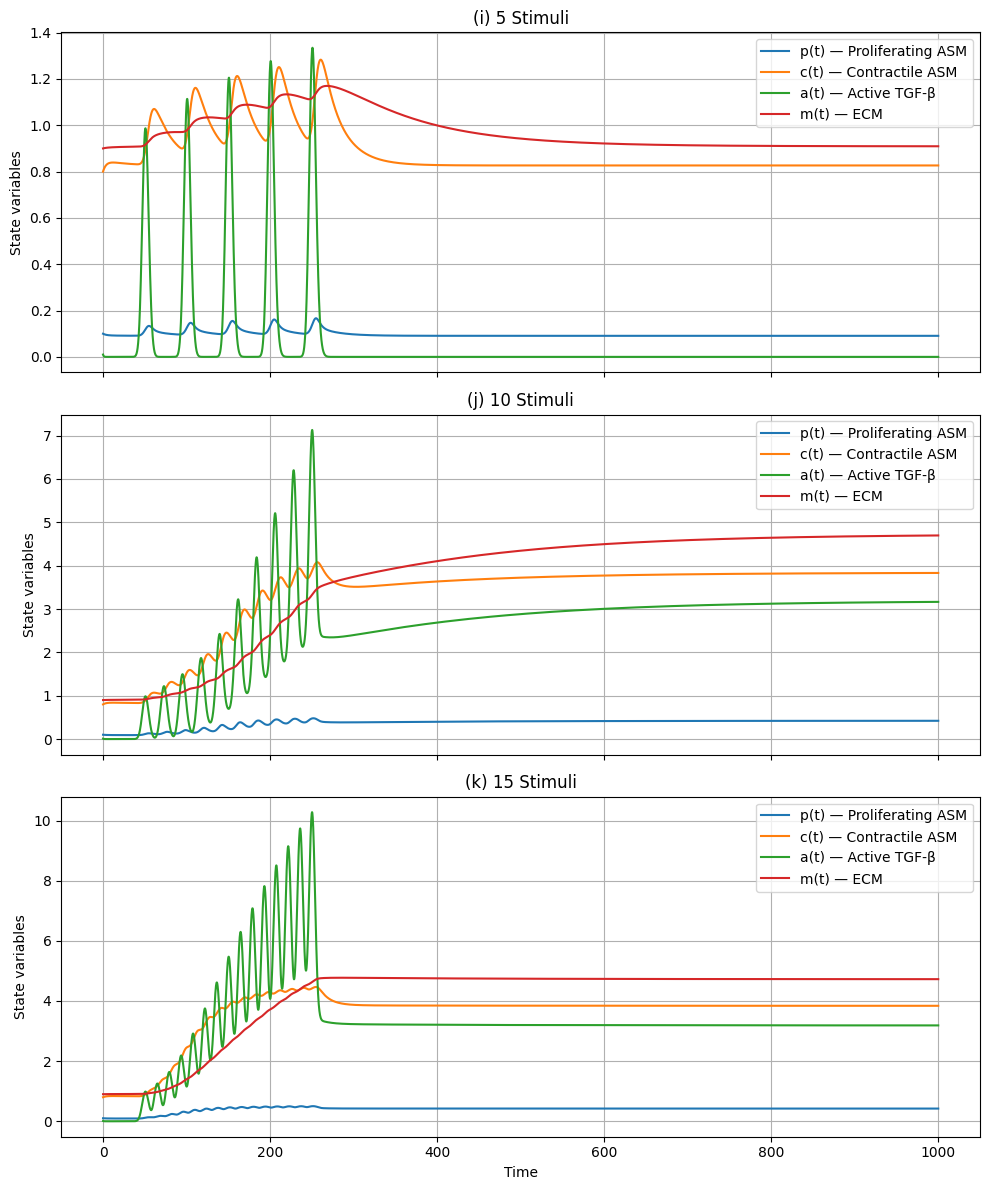

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the ODE system
def asthme_vector_field(t, y, params):
    p, c, a, m = y
    k_p = params["k_p"]
    p_max = params["p_max"]
    k_ap = params["k_ap"]
    eta_ap = params["eta_ap"]
    k_cp = params["k_cp"]
    gamma_c = params["gamma_c"]
    gamma_p = params["gamma_p"]
    k_pc = params["k_pc"]
    phi_c = params["phi_c"]
    k_s = params["k_s"]
    nu = params["nu"]
    t_is = params["t_i"]
    k_ac = params["k_ac"]
    eta_ac = params["eta_ac"]
    gamma_a = params["gamma_a"]
    k_b = params["k_b"]
    k_pm = params["k_pm"]
    k_apm = params["k_apm"]
    eta_apm = params["eta_apm"]
    phi_m = params["phi_m"]

    stimulus = sum((k_s / nu) * np.exp(-((t - t_i) ** 2) / nu ** 2) for t_i in t_is)

    dpdt = (
        k_p * p * (1 - p / p_max) * (1 + (k_ap * a * p) / (eta_ap + a * p))
        + k_cp * gamma_c / gamma_p * c
        - k_pc * p
    )
    dcdt = k_pc * gamma_p / gamma_c * p - (k_cp + phi_c) * c
    dadt = (
        (stimulus + (k_ac * a * c) / (eta_ac + a * c)) * c * m / gamma_a
        - k_b * (gamma_p * p / gamma_c + c) * a
        - a
    )
    dmdt = (
        (k_pm + (k_apm * a * p) / (eta_apm + a * p)) * gamma_p * p
        - phi_m * m
    )

    return [dpdt, dcdt, dadt, dmdt]

# Define parameter set (baseline from Pybus et al., 2023)
params = {
    "k_p": 1.0,
    "p_max": 1.0,
    "k_ap": 1.0,
    "eta_ap": 1.0,
    "k_cp": 0.01,
    "gamma_c": 1.0,
    "gamma_p": 1.0,
    "k_pc": 1.0,
    "phi_c": 0.1,
    "k_s": 0.1,
    "nu": 5.0,
    "t_i": [],  # Will be set in loop
    "k_ac": 0.01,
    "eta_ac": 1.0,
    "gamma_a": 0.01,
    "k_b": 1.0,
    "k_pm": 0.1,
    "k_apm": 0.1,
    "eta_apm": 10.0,
    "phi_m": 0.01
}

# Initial conditions
y0 = [0.1, 0.8, 0.01, 0.9]

# Time span
t_span = (0, 1000)
t_eval = np.linspace(*t_span, 5000)

# Define different stimulus numbers
stimulus_counts = [5, 10, 15]

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Function to generate equally spaced stimulus times
def generate_stimulus_times(n):
    return np.linspace(50, 250, n)

# Simulate and plot
for idx, n_stimuli in enumerate(stimulus_counts):
    t_is = generate_stimulus_times(n_stimuli)
    params["t_i"] = t_is.tolist()

    sol = solve_ivp(lambda t, y: asthme_vector_field(t, y, params),
                    t_span, y0, t_eval=t_eval, rtol=1e-6)

    ax = axes[idx]
    ax.plot(sol.t, sol.y[0], label="p(t) — Proliferating ASM")
    ax.plot(sol.t, sol.y[1], label="c(t) — Contractile ASM")
    ax.plot(sol.t, sol.y[2], label="a(t) — Active TGF-β")
    ax.plot(sol.t, sol.y[3], label="m(t) — ECM")

    ax.set_title(f"({chr(ord('i') + idx)}) {n_stimuli} Stimuli")
    ax.set_ylabel("State variables")
    ax.grid(True)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()
